<a href="https://colab.research.google.com/github/yerin010110/01_07_assignment/blob/main/01_07_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Google Drive를 Colab에 연결합니다
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Kaggle API 라이브러리 설치
!pip -q install kaggle

# Kaggle 설정 폴더 생성
!mkdir -p ~/.kaggle

# Drive에 저장된 kaggle.json을 Colab 홈으로 복사
!cp "/content/drive/MyDrive/랭체인 AI 영상객체탐지분석 플랫폼 구축/11.멀티모달/Kaggle/kaggle.json" ~/.kaggle/kaggle.json

# 권한 설정 (이거 안 하면 에러 납니다)
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets list | head

ref                                                  title                                         size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  --------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                             Heart Disease                                 3491  2025-12-11 15:29:14.327000           2114        207  1.0              
ahmeduzaki/wind-and-solar-energy-production-dataset  Wind & Solar Energy Production Dataset      395372  2026-01-02 21:06:22.780000              0         38  1.0              
kundanbedmutha/exam-score-prediction-dataset         Exam Score Prediction Dataset               325454  2025-11-28 07:29:01.047000           5863        251  1.0              
neurocipher/student-performance                      Student Performance                          49705  2025-12-12

In [ ]:
!kaggle datasets download -d andrewmvd/road-sign-detection -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/road-sign-detection
License(s): CC0-1.0
 71% 154M/218M [00:00<00:00, 1.60GB/s]
100% 218M/218M [00:00<00:00, 1.12GB/s]


In [ ]:
!ls -al /content

total 100
drwxr-xr-x 1 root root  4096 Jan  7 07:15 .
drwxr-xr-x 1 root root  4096 Jan  7 07:01 ..
drwxr-xr-x 2 root root 36864 Jan  7 07:15 annotations
drwxr-xr-x 4 root root  4096 Dec  9 14:41 .config
drwx------ 5 root root  4096 Jan  7 07:03 drive
drwxr-xr-x 2 root root 36864 Jan  7 07:15 images
drwxr-xr-x 1 root root  4096 Dec  9 14:42 sample_data


In [ ]:
import os, glob, random, shutil
import xml.etree.ElementTree as ET
import yaml

# 0 재현성 고정
random.seed(42)

# 1 원본 데이터 경로 (지금 예린님 출력 기준으로 확정)
SRC_IMG_DIR = "/content/images"
SRC_XML_DIR = "/content/annotations"

# 2 YOLO 출력 폴더
OUT_ROOT = "/content/road_sign_yolo"
OUT_IMG_TRAIN = os.path.join(OUT_ROOT, "images/train")
OUT_IMG_VAL   = os.path.join(OUT_ROOT, "images/val")
OUT_LAB_TRAIN = os.path.join(OUT_ROOT, "labels/train")
OUT_LAB_VAL   = os.path.join(OUT_ROOT, "labels/val")

for p in [OUT_IMG_TRAIN, OUT_IMG_VAL, OUT_LAB_TRAIN, OUT_LAB_VAL]:
    os.makedirs(p, exist_ok=True)

# 3 VOC XML 파싱 함수
def parse_voc(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    objs = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)
        objs.append((name, xmin, ymin, xmax, ymax))
    return w, h, objs

# 4 클래스 목록 자동 수집
xml_files = sorted(glob.glob(os.path.join(SRC_XML_DIR, "*.xml")))
classes = sorted({obj[0] for x in xml_files for obj in parse_voc(x)[2]})
class2id = {c:i for i,c in enumerate(classes)}

print("클래스 수:", len(classes))
print("클래스 목록:", classes[:20], "..." if len(classes) > 20 else "")

# 5 VOC 박스 -> YOLO 박스 변환
def voc_to_yolo(w, h, xmin, ymin, xmax, ymax):
    x_c = ((xmin + xmax) / 2.0) / w
    y_c = ((ymin + ymax) / 2.0) / h
    bw  = (xmax - xmin) / w
    bh  = (ymax - ymin) / h
    return x_c, y_c, bw, bh

# 6 train val 8:2 분리
random.shuffle(xml_files)
split = int(len(xml_files) * 0.8)
train_xml = xml_files[:split]
val_xml   = xml_files[split:]

# 7 이미지 확장자 혼재 대비용 함수
def find_image(base):
    for ext in [".jpg", ".jpeg", ".png"]:
        p = os.path.join(SRC_IMG_DIR, base + ext)
        if os.path.exists(p):
            return p
    return None

# 8 변환 및 복사
def process(xml_list, out_img_dir, out_lab_dir):
    ok = 0
    miss = 0
    for xml_path in xml_list:
        base = os.path.splitext(os.path.basename(xml_path))[0]
        img_path = find_image(base)

        if img_path is None:
            miss += 1
            continue

        w, h, objs = parse_voc(xml_path)

        # 라벨 txt 작성
        lines = []
        for (name, xmin, ymin, xmax, ymax) in objs:
            cid = class2id[name]
            x, y, bw, bh = voc_to_yolo(w, h, xmin, ymin, xmax, ymax)
            lines.append(f"{cid} {x:.6f} {y:.6f} {bw:.6f} {bh:.6f}")

        with open(os.path.join(out_lab_dir, base + ".txt"), "w") as f:
            f.write("\n".join(lines))

        # 이미지 복사
        shutil.copy2(img_path, os.path.join(out_img_dir, os.path.basename(img_path)))
        ok += 1

    return ok, miss

train_ok, train_miss = process(train_xml, OUT_IMG_TRAIN, OUT_LAB_TRAIN)
val_ok, val_miss     = process(val_xml, OUT_IMG_VAL, OUT_LAB_VAL)

print("train 변환 성공:", train_ok, "이미지 누락:", train_miss)
print("val 변환 성공:", val_ok, "이미지 누락:", val_miss)

# 9 data.yaml 생성
data = {
    "path": OUT_ROOT,
    "train": "images/train",
    "val": "images/val",
    "names": classes
}

yaml_path = os.path.join(OUT_ROOT, "data.yaml")
with open(yaml_path, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("data.yaml 생성 완료:", yaml_path)
print(open(yaml_path).read())

클래스 수: 4
클래스 목록: ['crosswalk', 'speedlimit', 'stop', 'trafficlight'] 
train 변환 성공: 701 이미지 누락: 0
val 변환 성공: 176 이미지 누락: 0
data.yaml 생성 완료: /content/road_sign_yolo/data.yaml
path: /content/road_sign_yolo
train: images/train
val: images/val
names:
- crosswalk
- speedlimit
- stop
- trafficlight



In [ ]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # 가볍고 빠른 모델
model.train(
    data="/content/road_sign_yolo/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    project="runs",
    name="road_sign_yolov8n"
)

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road_sign_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=road_sign_yolov8n2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e3287534e90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
import glob
glob.glob("runs/road_sign_yolov8n2/weights/best.pt")

['runs/road_sign_yolov8n2/weights/best.pt']

In [ ]:
from ultralytics import YOLO

best_path = "runs/road_sign_yolov8n2/weights/best.pt"
model = YOLO(best_path)

model.predict(
    source="/content/road_sign_yolo/images/val",
    conf=0.25,
    save=True,
    project="runs",
    name="road_sign_predict"
)


image 1/176 /content/road_sign_yolo/images/val/road100.png: 640x640 3 speedlimits, 7.3ms
image 2/176 /content/road_sign_yolo/images/val/road103.png: 512x640 1 speedlimit, 41.8ms
image 3/176 /content/road_sign_yolo/images/val/road108.png: 416x640 1 speedlimit, 38.4ms
image 4/176 /content/road_sign_yolo/images/val/road120.png: 480x640 1 speedlimit, 38.2ms
image 5/176 /content/road_sign_yolo/images/val/road122.png: 640x416 1 crosswalk, 36.9ms
image 6/176 /content/road_sign_yolo/images/val/road125.png: 640x448 1 crosswalk, 40.0ms
image 7/176 /content/road_sign_yolo/images/val/road127.png: 448x640 1 crosswalk, 46.2ms
image 8/176 /content/road_sign_yolo/images/val/road138.png: 480x640 1 crosswalk, 8.5ms
image 9/176 /content/road_sign_yolo/images/val/road14.png: 640x448 1 trafficlight, 6.7ms
image 10/176 /content/road_sign_yolo/images/val/road141.png: 384x640 1 crosswalk, 39.9ms
image 11/176 /content/road_sign_yolo/images/val/road15.png: 448x640 3 trafficlights, 6.8ms
image 12/176 /content/r

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crosswalk', 1: 'speedlimit', 2: 'stop', 3: 'trafficlight'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [ 20,  40,  35],
         [ 22,  42,  36],
         [ 23,  42,  36]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [ 20,  40,  35],
         [ 22,  42,  36],
         [ 23,  42,  36]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [ 20,  42,  35],
         [ 21,  42,  36],
         [ 21,  42,  36]],
 
        ...,
 
        [[ 82, 101, 114],
         [ 83, 102, 114],
         [ 83, 103, 116],
         ...,
         [ 26,  76,  68],
         [ 22,  72,  63],
         [ 20,  70,  61]],
 
        [[ 84, 103, 115],
         [ 84, 103, 115],
        

In [ ]:
!ls -al runs

total 20
drwxr-xr-x 5 root root 4096 Jan  7 07:32 .
drwxr-xr-x 1 root root 4096 Jan  7 07:17 ..
drwxr-xr-x 2 root root 4096 Jan  7 07:32 road_sign_predict
drwxr-xr-x 3 root root 4096 Jan  7 07:18 road_sign_yolov8n
drwxr-xr-x 3 root root 4096 Jan  7 07:27 road_sign_yolov8n2


In [ ]:
!ls -al runs/road_sign_yolov8n/weights

total 36064
drwxr-xr-x 2 root root     4096 Jan  7 07:18 .
drwxr-xr-x 3 root root     4096 Jan  7 07:18 ..
-rw-r--r-- 1 root root 18458019 Jan  7 07:20 best.pt
-rw-r--r-- 1 root root 18458275 Jan  7 07:21 last.pt


In [ ]:
!ls -al runs/road_sign_yolov8n2/weights

total 12184
drwxr-xr-x 2 root root    4096 Jan  7 07:21 .
drwxr-xr-x 3 root root    4096 Jan  7 07:27 ..
-rw-r--r-- 1 root root 6233002 Jan  7 07:27 best.pt
-rw-r--r-- 1 root root 6233002 Jan  7 07:27 last.pt


In [ ]:
!cp -r runs/road_sign_predict "/content/drive/MyDrive/11.멀티모달/"

In [ ]:
!ls -al "/content/drive/MyDrive/11.멀티모달/road_sign_predict"

ls: cannot access '/content/drive/MyDrive/11.멀티모달/road_sign_predict': No such file or directory


In [ ]:
!cp -r runs/road_sign_predict "/content/drive/MyDrive/11_multimodal/"

In [ ]:
!find "/content/drive/MyDrive/11_multimodal" -maxdepth 2 -type f

/content/drive/MyDrive/11_multimodal/road100.jpg
/content/drive/MyDrive/11_multimodal/road103.jpg
/content/drive/MyDrive/11_multimodal/road108.jpg
/content/drive/MyDrive/11_multimodal/road120.jpg
/content/drive/MyDrive/11_multimodal/road122.jpg
/content/drive/MyDrive/11_multimodal/road125.jpg
/content/drive/MyDrive/11_multimodal/road127.jpg
/content/drive/MyDrive/11_multimodal/road138.jpg
/content/drive/MyDrive/11_multimodal/road14.jpg
/content/drive/MyDrive/11_multimodal/road141.jpg
/content/drive/MyDrive/11_multimodal/road15.jpg
/content/drive/MyDrive/11_multimodal/road157.jpg
/content/drive/MyDrive/11_multimodal/road159.jpg
/content/drive/MyDrive/11_multimodal/road162.jpg
/content/drive/MyDrive/11_multimodal/road164.jpg
/content/drive/MyDrive/11_multimodal/road170.jpg
/content/drive/MyDrive/11_multimodal/road171.jpg
/content/drive/MyDrive/11_multimodal/road179.jpg
/content/drive/MyDrive/11_multimodal/road182.jpg
/content/drive/MyDrive/11_multimodal/road183.jpg
/content/drive/MyDrive

(np.float64(-0.5), np.float64(399.5), np.float64(264.5), np.float64(-0.5))

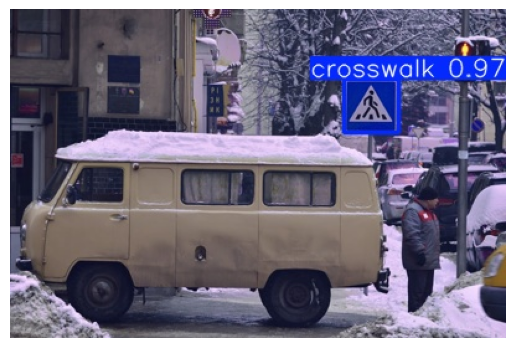

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/11_multimodal/road127.jpg")
plt.imshow(img)
plt.axis("off")

In [47]:
results = model.predict(
    source="/content/road_sign_yolo/images/val",
    save=True
)


image 1/176 /content/road_sign_yolo/images/val/road100.png: 640x640 3 speedlimits, 14.1ms
image 2/176 /content/road_sign_yolo/images/val/road103.png: 512x640 1 speedlimit, 11.7ms
image 3/176 /content/road_sign_yolo/images/val/road108.png: 416x640 1 speedlimit, 13.0ms
image 4/176 /content/road_sign_yolo/images/val/road120.png: 480x640 1 speedlimit, 13.0ms
image 5/176 /content/road_sign_yolo/images/val/road122.png: 640x416 1 crosswalk, 12.2ms
image 6/176 /content/road_sign_yolo/images/val/road125.png: 640x448 1 crosswalk, 15.4ms
image 7/176 /content/road_sign_yolo/images/val/road127.png: 448x640 1 crosswalk, 12.8ms
image 8/176 /content/road_sign_yolo/images/val/road138.png: 480x640 1 crosswalk, 11.8ms
image 9/176 /content/road_sign_yolo/images/val/road14.png: 640x448 1 trafficlight, 19.8ms
image 10/176 /content/road_sign_yolo/images/val/road141.png: 384x640 1 crosswalk, 15.4ms
image 11/176 /content/road_sign_yolo/images/val/road15.png: 448x640 3 trafficlights, 11.9ms
image 12/176 /conte

(np.float64(-0.5), np.float64(299.5), np.float64(399.5), np.float64(-0.5))

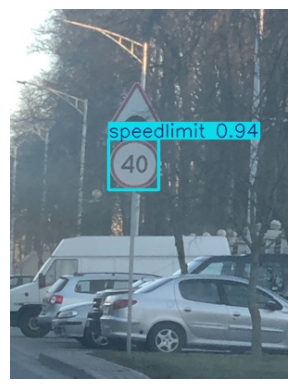

In [58]:
img = Image.open("/content/runs/road_sign_predict/road369.jpg")
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(267.5), np.float64(399.5), np.float64(-0.5))

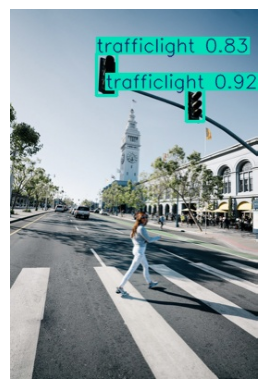

In [57]:
img = Image.open("/content/runs/road_sign_predict/road44.jpg")
plt.imshow(img)
plt.axis("off")